In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

# 2. Look at the raw data
print("Movies Data:")
print(movies.head())

print("\nRatings Data:")
print(ratings.head())

# 3. Merge them so we have titles and ratings together
df = pd.merge(ratings, movies, on='movieId')

print("\nMerged Data:")
df.head()

Movies Data:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  

Ratings Data:
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931

Merged Data:


,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


                                           average_rating  rating_count
title                                                                  
Forrest Gump (1994)                              4.164134           329
Shawshank Redemption, The (1994)                 4.429022           317
Pulp Fiction (1994)                              4.197068           307
Silence of the Lambs, The (1991)                 4.161290           279
Matrix, The (1999)                               4.192446           278
Star Wars: Episode IV - A New Hope (1977)        4.231076           251
Jurassic Park (1993)                             3.750000           238
Braveheart (1995)                                4.031646           237
Terminator 2: Judgment Day (1991)                3.970982           224
Schindler's List (1993)                          4.225000           220


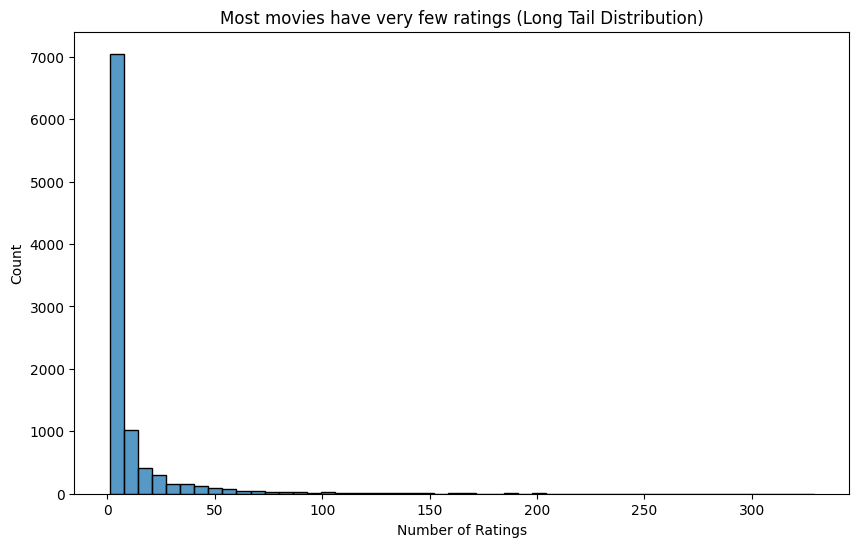

In [7]:
# 1. Group by Title and calculate the Mean rating and the Count of ratings
movie_stats = df.groupby('title')['rating'].agg(['mean', 'count'])

# 2. Rename columns for clarity
movie_stats.columns = ['average_rating', 'rating_count']

# 3. Look at the top 10 most rated movies
print(movie_stats.sort_values(by='rating_count', ascending=False).head(10))

# 4. Let's look at the distribution
plt.figure(figsize=(10,6))
sns.histplot(movie_stats['rating_count'], bins=50)
plt.title("Most movies have very few ratings (Long Tail Distribution)")
plt.xlabel("Number of Ratings")
plt.show()

In [9]:
# 1. Create the Pivot Table
# This lines up every user against every movie
matrix = df.pivot_table(index='userId', columns='title', values='rating')

# 2. Look at the matrix
matrix.head()

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# 1. Get the ratings for Forrest Gump
gump_ratings = matrix['Forrest Gump (1994)']

# 2. Calculate the correlation with every other movie
# This compares the "Gump" column to every single other column
similar_to_gump = matrix.corrwith(gump_ratings)

# 3. Convert it to a DataFrame so we can sort it
corr_gump = pd.DataFrame(similar_to_gump, columns=['Correlation'])

# 4. Drop NaN values (movies that nobody rated in common with Gump)
corr_gump.dropna(inplace=True)

# 5. Sort by correlation (Highest match first)
print(corr_gump.sort_values(by='Correlation', ascending=False).head(10))

c:\Users\Waleed\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:3015: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\Waleed\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\Waleed\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
c:\Users\Waleed\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Waleed\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


                                            Correlation
title                                                  
World's Greatest Dad (2009)                         1.0
2001 Maniacs (2005)                                 1.0
Family Plot (1976)                                  1.0
New York, I Love You (2009)                         1.0
Mr. Jealousy (1997)                                 1.0
Chasers (1994)                                      1.0
Eye for an Eye (1996)                               1.0
Extremely Loud and Incredibly Close (2011)          1.0
Exodus: Gods and Kings (2014)                       1.0
Wolfman, The (2010)                                 1.0


In [11]:
# 1. Join our Correlation table with the Rating Counts we calculated earlier
corr_gump = corr_gump.join(movie_stats['rating_count'])

# 2. Filter out movies with fewer than 50 ratings
# This removes the "1-person wonders"
popular_recs = corr_gump[corr_gump['rating_count'] > 50].sort_values(by='Correlation', ascending=False)

# 3. Print the REAL top 10 recommendations
popular_recs.head(10)

,Correlation,rating_count
title,,
Forrest Gump (1994),1.000000,329
Mr. Holland's Opus (1995),0.652144,80
Pocahontas (1995),0.550118,68
Grumpier Old Men (1995),0.534682,52
Caddyshack (1980),0.520328,52
"Few Good Men, A (1992)",0.517146,57
Field of Dreams (1989),0.503845,56
Big (1988),0.492351,91
Hook (1991),0.484676,53


In [30]:
from thefuzz import process

def recommend_movie(user_input):
    # 1. Get all titles
    all_titles = matrix.columns.tolist()
    
    # 2. Find the single best match using "extractOne"
    # limit=1 gives us the top match
    # scorer=process.fuzz.token_sort_ratio is the magic. 
    # It ignores word order and handles typos.
    match = process.extractOne(user_input, all_titles, scorer=process.fuzz.token_sort_ratio)
    
    # match returns a tuple: ('Matrix, The (1999)', 85) -> (Title, Score)
    best_title = match[0]
    score = match[1]
    
    # 3. Set a confidence threshold (e.g., must be 60% similar)
    if score < 60:
        return f"Sorry, I couldn't find anything close to '{user_input}'. Did you mean '{best_title}'?"
    
    print(f"Found match: '{best_title}' (Similarity Score: {score}/100)\n")
    
    # --- Standard Recommendation Logic ---
    movie_user_ratings = matrix[best_title]
    similar_to_movie = matrix.corrwith(movie_user_ratings)
    
    corr_movie = pd.DataFrame(similar_to_movie, columns=['Correlation'])
    corr_movie = corr_movie.join(movie_stats['rating_count'])
    
    recommendations = corr_movie[corr_movie['rating_count'] > 50].sort_values(by='Correlation', ascending=False)
    
    # Skip the first one (it's the movie itself) and return top 10
    return recommendations.iloc[1:].head(10)

In [32]:
# TEST IT WITH TYPOS!
recommend_movie("foret gum 1994")

Found match: 'Forrest Gump (1994)' (Similarity Score: 90/100)



c:\Users\Waleed\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:3015: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\Waleed\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\Waleed\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
c:\Users\Waleed\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Waleed\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,Correlation,rating_count
title,,
Mr. Holland's Opus (1995),0.652144,80
Pocahontas (1995),0.550118,68
Grumpier Old Men (1995),0.534682,52
Caddyshack (1980),0.520328,52
"Few Good Men, A (1992)",0.517146,57
Field of Dreams (1989),0.503845,56
Big (1988),0.492351,91
Hook (1991),0.484676,53
Good Will Hunting (1997),0.484042,141
